<a href="https://colab.research.google.com/github/marxjoseph/SYSC4415A2/blob/main/W2026/Assignments/A2/A2_SYSC4415_W26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SYSC4415 W26 Assignment 2 – Fire Hydrant Detection 🚒

Special thanks to Nader Ibrahim for assembling the dataset. For more details, please refer to the paper:

Ibrahim N, Dick K, Green JR. Computer Vision Fire Hydrant Obstruction Detection System. In2024 IEEE Canadian Conference on Electrical and Computer Engineering (CCECE) 2024 Aug 6 (pp. 799-805). IEEE.


Questions? Please use the Brightspace Discussion Board.

Deadline: See Brightspace end date.

## Instructions
DO NOT wait until the last minute to complete this assignment as training the models might take longer. Also leverage the free GPU provided by colab to make your training faster.


Follow all steps carefully. Your solutions must be self-contained in this notebook. No other supplementary materials or files will be accepted. As soon as I open your notebook, I will click "Runtime" → "Run all". Ensure your notebook runs without errors and displays results clearly.


You are asked to provide both code and text to address discussion questions. For the text answers, see the markdown cells with the ❓ emoji for questions and enter your answers following the ✅ emoji.

Provide sufficient comments in your code to describe its functionality. Do not remove any necessary libraries as this will cause errors.

Download the dataset from Brightspace and store it in your Google Drive under "My Drive" (not in any subfolder). Check the file location via right-click → File Information → Details → Location.

Submit your notebook as a `.ipynb` file named: `SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb` on Brightspace. No other submission methods will be accepted.


## Dataset
Provided on Brightspace.

#### Dataset details:
- Training Images: 2,272  
- Validation Images: 563  
- Labels: 0 = No Fire Hydrant, 1 = Fire Hydrant  
- Imbalanced dataset (most images do not contain a hydrant).

#### Dataset Information
The dataset contains two main folders:
- `train/`: Contains the training images and a CSV file with labels.
- `valid/`: Contains the validation images and a CSV file with labels.

Each folder includes:
- Images of fire hydrants and non-fire hydrants.
- A CSV file (`_classes.csv`) mapping each image filename to its label:
  - `0` for no fire hydrant.
  - `1` for fire hydrant.

Ensure the zip file of the dataset (FH_detection_data.zip) to your Google Drive and placed under "My Drive" without any subfolders to keep the paths consistent.



## Steps

### 1) Initial Setup
Import necessary libraries


In [5]:
# Import all the necessary libraries here

import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import TensorDataset, Dataset, DataLoader
import torch
import torch.nn as nn
from torch import optim
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

Mount Google Drive and unzip the dataset.

In [6]:
## Code provided by TA. DO NOT CHANGE THIS CELL

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
!unzip /content/drive/MyDrive/FH_detection_data.zip -d /content/


# Dataset path
train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')

Mounted at /content/drive
Archive:  /content/drive/MyDrive/FH_detection_data.zip
   creating: /content/train/
 extracting: /content/train/10063782964_891eedde4e_z_jpg.rf.4caba9d0e35546b469aa896df780d833.jpg  
 extracting: /content/train/100_PNG.rf.d52fbff94c483761d0644a1e8abe4c95.jpg  
 extracting: /content/train/101_PNG.rf.f1335e18f815c8c8044a94c09db7f025.jpg  
 extracting: /content/train/102378468_d8132a415b_z_jpg.rf.6bc008d0d532d3365f580b7aaa7623e3.jpg  
 extracting: /content/train/102_PNG.rf.160c945e0881c92a078a14069d9a6b9a.jpg  
 extracting: /content/train/102_jpg.rf.17df75e9dda0f851c9f5e1d554f07488.jpg  
 extracting: /content/train/103357395_388d701e12_z_jpg.rf.a54c985e93402af49ba422f005e702d8.jpg  
 extracting: /content/train/103_jpg.rf.a649213f3998906bf2298607f82ee839.jpg  
 extracting: /content/train/104351403_25e959f878_z_jpg.rf.43156bd0a74313df69967d88e5e6a268.jpg  
 extracting: /content/train/104_PNG.rf.c14671a6a52ae05f9ae2bf1df7e4316e.jpg  
 extracting: /content/train/104_

----

### 2) Data Exploration
1. Load dataset into a pandas DataFrame.
2. Display display three sample images from each class
3. Create separately class distribution plots of the train and validation data
[Requires 6 sample images (three from each class) and two plots of class distribution (train and validation)]

❓ Why is it important to check for class imbalance before training? How might this affect our model?  
✅ It is important to check for class imbalance because a skewed dataset can bias the moderd in favor of the majority class. This would lead to misleading high accuracy for the model while the model fails its actual purpose.


Class 0 No Fire Hydrant:


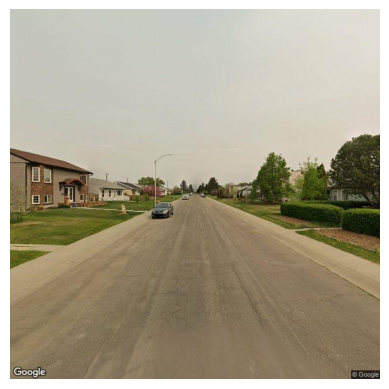

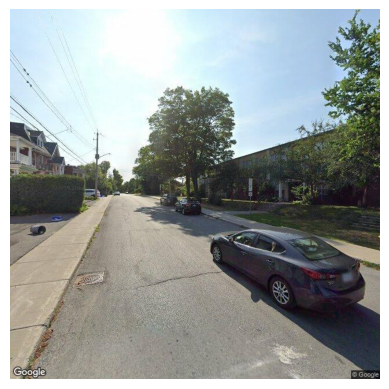

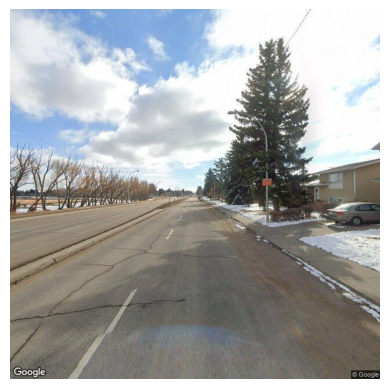


Class 1 Has Fire Hydrant:


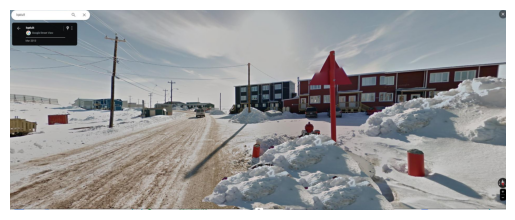

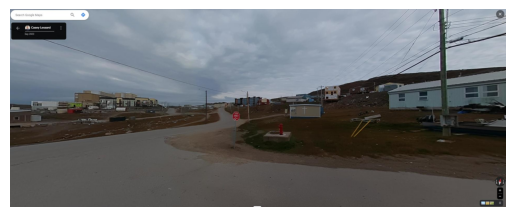

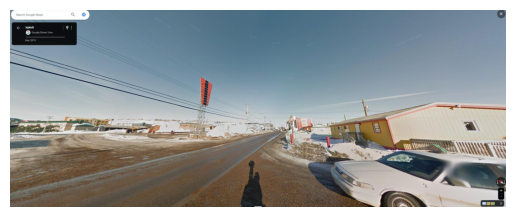


Training set class distribution:


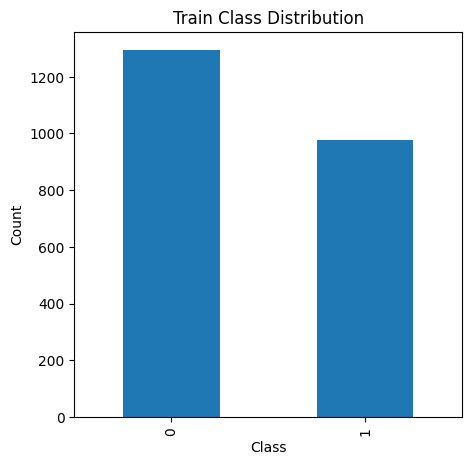


Validation set class distribution:


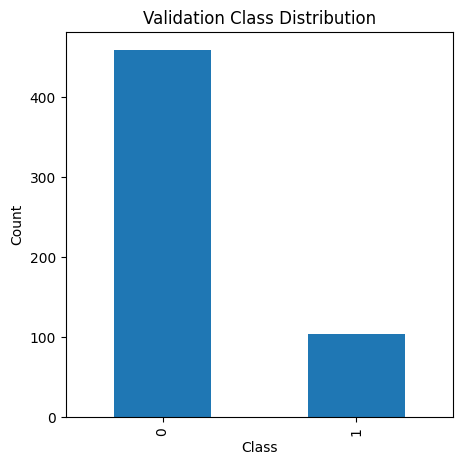

In [7]:
# Strip whitespace
train_label.columns = train_label.columns.str.strip()
valid_label.columns = valid_label.columns.str.strip()

# Store in pandas DataFrame
train_df = pd.DataFrame(train_label)
valid_df = pd.DataFrame(valid_label)

# Separate by class
zero_hydrant = train_df[train_df["Fire Hydrants"] == 0].sample(3)
one_hydrant = train_df[train_df["Fire Hydrants"] == 1].sample(3)

# Show sample images for all calsses
print("Class 0 No Fire Hydrant:")
for _, row in zero_hydrant.iterrows():
  img = Image.open(os.path.join(train_data_path, row['filename']))
  plt.imshow(img)
  plt.axis('off')
  plt.show()
print("\nClass 1 Has Fire Hydrant:")
for _, row in one_hydrant.iterrows():
  img = Image.open(os.path.join(train_data_path, row['filename']))
  plt.imshow(img)
  plt.axis('off')
  plt.show()

# Class distribution
print("\nTraining set class distribution:")
train_df["Fire Hydrants"].value_counts().plot(kind='bar', figsize=(5,5))
plt.title("Train Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()
print("\nValidation set class distribution:")
valid_df["Fire Hydrants"].value_counts().plot(kind='bar', figsize=(5,5))
plt.title("Validation Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

---

### 3) Preprocessing
- Resize images to 128x128.
- Apply any other necessary transformations that you feel can help.

❓ Would one-hot encoding be necessary for binary classification? Why or why not?  
✅ One-hot encoding for binary classification isn't needed because the values 0 and 1 already represent the classes. Another column is not needed when the binary format already works.

In [9]:
# Transformations for Training
data_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Dataset
class FireHydrantDataset(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df
        self.data_path = data_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.data_path, row['filename']))
        label = row['Fire Hydrants']
        if self.transform:
            img = self.transform(img)
        return img, label

# Apply transforms
train_dataset = FireHydrantDataset(train_df, train_data_path, transform=data_transforms)
valid_dataset = FireHydrantDataset(valid_df, valid_data_path, transform=data_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

---

### 4) Creating the Baseline Model
Create a CNN with:
- Two convolutional layers to extract features from the images.
- Max pooling layers after each convolution to reduce spatial dimensions.
- Fully connected layers to perform classification.
- A sigmoid activation function at the output layer to output a probability between 0 and 1.

Required architecture:
- Input: RGB images resized to 128x128 pixels.
- Conv2d (3 input channels, 32 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the first Conv2d.
- Conv2d (32 input channels, 64 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the second Conv2d.
- Flatten
- Linear layer with 128 units
- Output Linear layer with 1 unit and sigmoid activation



This model will be trained to classify whether an image contains a fire hydrant or not.


❓ List three ways to improve the baseline model (e.g., adding dropout to... , using batch normalization to..., or increasing the number of layers to...,
be sure to come up with your own ideas!). Provide a brief explanation for each.

✅ Add a dropout after the fully connected layer which can help prevent overfitting. Use batch normalization after each convolution which can help speed up training. Add another convolutional layer with more filters which can help the model learn more complex patterns.

In [10]:
# Baseline Model
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

# Create model and print
model = BaselineCNN()
print(model)

BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


---

### 5) Training and Evaluation
Train your CNN using Binary Cross Entropy Loss and an Adam optimizer. Use a learning rate of 0.001. Iterate over your dataset for 10 epochs and track the loss. Train using the train data in /train.

Evaluate your model on the test data in /valid using Precision, Recall, and F1-Score to assess performance.


❓ Which evaluation metric you think is the most suitable in our case, and why?

✅ The evaluation metric I think is the most suitable in my case is the F1 score because of the imbalanced dataset. F1 score gives a balanced metric that will take a look at both the precision and recall.

Display the confusion matrix.

❓ Explain the confusion matrix to a non-technical audience and relate it to your chosen metric.  
✅ A confusion matrix is a simple diagram that displays how well the model is working. It has a score for four categories which are correctly identified no fire hydrant, correctly identified fire hydrant, flagged a fire hydrant which wasn't there, and didn't identify a fire hydrant that was there. The F1 score is based on these numbers which helps balance the precision and recall.


Epoch 1/10, Loss: 0.6306
Epoch 2/10, Loss: 0.5007
Epoch 3/10, Loss: 0.4331
Epoch 4/10, Loss: 0.3848
Epoch 5/10, Loss: 0.2936
Epoch 6/10, Loss: 0.1982
Epoch 7/10, Loss: 0.1298
Epoch 8/10, Loss: 0.0783
Epoch 9/10, Loss: 0.0502
Epoch 10/10, Loss: 0.0354

Performance Metrics

Precision: 0.3943
Recall:    0.6635
F1-Score:  0.4946


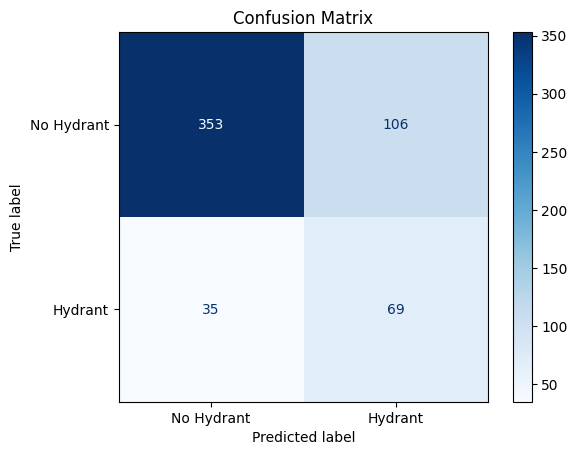

In [11]:
# Train the model
loss_func = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(10):
    model.train()
    epoch_loss = 0.0
    for X, y in train_loader:
        optimizer.zero_grad()
        loss = loss_func(model(X), y.float().unsqueeze(1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/10, Loss: {epoch_loss/len(train_loader):.4f}")

# Evaluate the model
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X, y in valid_loader:
        preds = (model(X) >= 0.5).float()
        all_preds.extend(preds.squeeze().tolist())
        all_labels.extend(y.tolist())

# Print performance metrics
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
print("\nPerformance Metrics")
print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Display confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Hydrant', 'Hydrant'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

---


### 6) Model Improvements
Apply and evaluate three improvements ideas that you mentioned in the Baseline CNN question (Step 4).
Implement each idea separately, train a model with that improvement, and report the performance of each model using the metrics from Step 5. As above, train using the data in /train and test using the data in /valid.


❓ Which model would you deploy? Why?  
✅ Your answer here

Epoch 1/10, Loss: 0.5934
Epoch 2/10, Loss: 0.4878
Epoch 3/10, Loss: 0.4459
Epoch 4/10, Loss: 0.3810
Epoch 5/10, Loss: 0.3182
Epoch 6/10, Loss: 0.2578
Epoch 7/10, Loss: 0.1909
Epoch 8/10, Loss: 0.1498
Epoch 9/10, Loss: 0.1062
Epoch 10/10, Loss: 0.0881

Dropout Results:
Precision: 0.4828
Recall:    0.6731
F1-Score:  0.5622


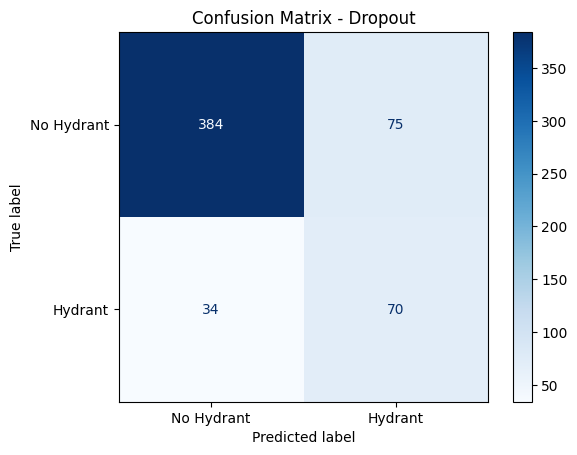

Epoch 1/10, Loss: 55.3796
Epoch 2/10, Loss: 56.9542
Epoch 3/10, Loss: 56.9542
Epoch 4/10, Loss: 56.9542
Epoch 5/10, Loss: 56.9542
Epoch 6/10, Loss: 56.9542
Epoch 7/10, Loss: 56.9542
Epoch 8/10, Loss: 56.9542
Epoch 9/10, Loss: 56.9542
Epoch 10/10, Loss: 56.9542

Batch Norm Results:
Precision: 0.1847
Recall:    1.0000
F1-Score:  0.3118


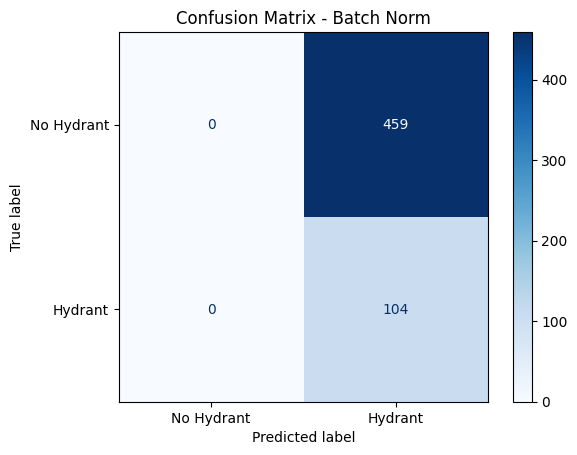

Epoch 1/10, Loss: 0.6104
Epoch 2/10, Loss: 0.5093
Epoch 3/10, Loss: 0.4742
Epoch 4/10, Loss: 0.4418
Epoch 5/10, Loss: 0.4029
Epoch 6/10, Loss: 0.3695
Epoch 7/10, Loss: 0.3038
Epoch 8/10, Loss: 0.2386
Epoch 9/10, Loss: 0.1863
Epoch 10/10, Loss: 0.1198

Extra Layer Results:
Precision: 0.4277
Recall:    0.6827
F1-Score:  0.5259


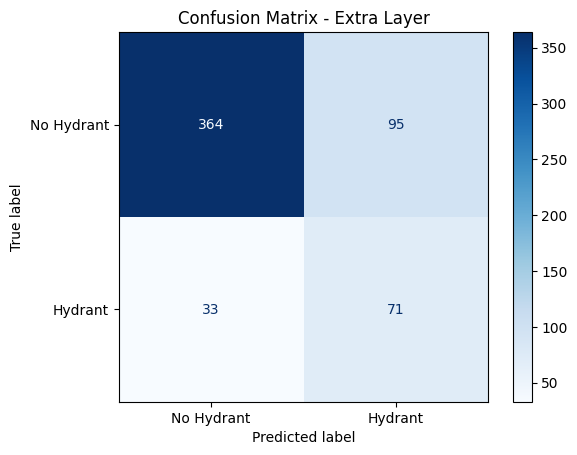

In [12]:
# Model 1 - Dropout
class CNNWithDropout(nn.Module):
    def __init__(self):
        super(CNNWithDropout, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.sigmoid(self.fc2(x))
        return x

# Model 2 - Batch Normalization
class CNNWithBatchNorm(nn.Module):
    def __init__(self):
        super(CNNWithBatchNorm, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

# Model 3 - Extra Conv Layer
class CNNWithExtraLayer(nn.Module):
    def __init__(self):
        super(CNNWithExtraLayer, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x


for model, name in [(CNNWithDropout(), "Dropout"),
                    (CNNWithBatchNorm(), "Batch Norm"),
                    (CNNWithExtraLayer(), "Extra Layer")]:

  optimizer = optim.Adam(model.parameters(), lr=0.001)
  loss_fn = nn.BCELoss()

  # Train
  for epoch in range(10):
      model.train()
      epoch_loss = 0.0
      for X, y in train_loader:
          optimizer.zero_grad()
          loss = loss_fn(model(X), y.float().unsqueeze(1))
          loss.backward()
          optimizer.step()
          epoch_loss += loss.item()
      print(f"Epoch {epoch+1}/10, Loss: {epoch_loss/len(train_loader):.4f}")

  # Evaluate
  model.eval()
  all_preds, all_labels = [], []
  with torch.no_grad():
      for X, y in valid_loader:
          preds = (model(X) >= 0.5).float()
          all_preds.extend(preds.squeeze().tolist())
          all_labels.extend(y.tolist())

  print(f"\n{name} Results:")
  print(f"Precision: {precision_score(all_labels, all_preds):.4f}")
  print(f"Recall:    {recall_score(all_labels, all_preds):.4f}")
  print(f"F1-Score:  {f1_score(all_labels, all_preds):.4f}")

  cm = confusion_matrix(all_labels, all_preds)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Hydrant', 'Hydrant'])
  disp.plot(cmap='Blues')
  plt.title(f"Confusion Matrix - {name}")
  plt.show()

---

### 7) Personal Inference Test
Test your trained model on at least FIVE new images (either collected using a camera or collected from the internet). Predict whether each image contains a fire hydrant and print the result.

Of your five images:
- Include at least one image of a fire hydrant that your model does not detect correctly.
- Include at least one image of a fire hydrant that your model does detect correctly.

❓ Challenge: Can you find an image that does not actually contain a fire hydrant, but your model believes that a hydrant is present?

✅ Your answer here

❓ Explain why you believe your model performed the way it did on each of your five images. What patterns or mistakes do you observe?

✅ Your answer here


In [ ]:
## Enter your code here..

---

### 8) (Optional) Transfer Learning with Pretrained CNN

#### Description:
In this optional step, fine-tune a pretrained CNN (e.g., ResNet50) on your dataset and compare its performance to your custom CNN.

- Use `torchvision.models.resnet50(pretrained=True)` as a starting model.

Reference: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
- Modify the final layer to fit your binary classification task (fire hydrant vs. no fire hydrant).
- Resize input images to **256x256** pixels.
- Fine-tune the model and evaluate its performance.
- Compare the results to your custom CNN in terms of accuracy, training time, and other relevant metrics.

#### Libraries to use:
```python
import torchvision.models as models
```

#### Student Code:
```python
# Your code here
```


------

### 9) Final Thoughts
❓ How would you improve the model in the future?

✅ Your answer here..


-----

## Final Question:
### ❓ Did you use an AI tool in completing your assignment? If yes, which AI tool(s) did you use? How did you prompt it? How you validate the response?

✅ Your answer here..


---

## Submission
Submit your `.ipynb` notebook on Brightspace using the following name format:  
`SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb`

